#  Kapitel 2.2 - Ett kodexempel från början till slut - Huspriser i Kalifornien

Denna notebook visar en komplett ML-pipeline för att prediktera huspriser i Kalifornien.

##  Innehåll:
1. **Data laddning och förståelse**
2. **Data preprocessing och rensning**
3. **Exploratory Data Analysis (EDA)**
4. **Datauppdelning (train/validation/test)**
5. **Modellering och träning**
6. **Hyperparameteroptimering**
7. **Utvärdering och prediktioner**
8. **Modellsparning och användning**

---

##  1. Importera nödvändiga bibliotek

Först importerar vi alla bibliotek vi behöver för ML-projektet.

In [1]:
# Grundläggande bibliotek för datamanipulation och visualisering
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Scikit-learn bibliotek för ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error  # Notera: root_mean_squared_error finns inte i sklearn
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# För att läsa bilder
import matplotlib.image as mpimg

# För att spara modeller
import joblib

# Sätt stil för plots
plt.style.use('default')
sns.set_palette("husl")

print(" Alla bibliotek importerade!")

 Alla bibliotek importerade!


##  2. Data laddning och förståelse

Vi laddar in California Housing dataset och utforskar dess struktur.

In [2]:
# Ladda dataset från CSV-fil
# Notera: Du behöver ha housing.csv i samma mapp
housing_original = pd.read_csv("housing.csv")

# Visa grundläggande information om dataset
print(" Dataset information:")
housing_original.info()

print("\n Första 6 kolumnerna:")
print(housing_original.iloc[:, :6].head())

print("\n Sista kolumnerna:")
print(housing_original.iloc[:, 5:].head())

print("\n Ocean proximity kategorier:")
print(housing_original['ocean_proximity'].value_counts())

 Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

 Första 6 kolumnerna:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0 

##  3. Data preprocessing och rensning

Vi rensar datan och förbereder den för modellering.

In [3]:
# Ta bort ISLAND-kategorin eftersom den har för få observationer
housing = housing_original[housing_original['ocean_proximity'] != 'ISLAND']

print(" Ocean proximity kategorier efter rensning:")
print(housing['ocean_proximity'].value_counts())

# Konvertera kategorisk variabel till dummy-variabler (one-hot encoding)
housing = pd.get_dummies(housing, columns=['ocean_proximity'], 
                        dtype=int, prefix='dmy')

print("\n Exempel på dummy-variabler:")
print(housing.iloc[[1, 200, 1000, 1850, 5000], 9:])

 Ocean proximity kategorier efter rensning:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
Name: count, dtype: int64

 Exempel på dummy-variabler:
      dmy_<1H OCEAN  dmy_INLAND  dmy_NEAR BAY  dmy_NEAR OCEAN
1                 0           0             1               0
200               0           0             1               0
1000              0           1             0               0
1850              0           0             0               1
5000              1           0             0               0


##  4. Datauppdelning (Train/Validation/Test)

Vi delar upp datan i träning, validering och test-set.

In [4]:
# Första uppdelning: 80% träning+validering, 20% test
train_full, test = train_test_split(housing, test_size=0.2, random_state=40)

# Andra uppdelning: 75% träning, 25% validering
train, val = train_test_split(train_full, test_size=0.25, random_state=36)

print(" Datauppdelning:")
print(f"Träning: {train.shape[0]} rader ({train.shape[0]/len(housing)*100:.1f}%)")
print(f"Validering: {val.shape[0]} rader ({val.shape[0]/len(housing)*100:.1f}%)")
print(f"Test: {test.shape[0]} rader ({test.shape[0]/len(housing)*100:.1f}%)")

print("\n Träningsdata info:")
train.info()

# Ta bort rader med saknade värden
train = train.dropna()
val = val.dropna()
test = test.dropna()

print("\n Saknade värden borttagna!")
print(f"Träning efter rensning: {train.shape[0]} rader")
print(f"Validering efter rensning: {val.shape[0]} rader")
print(f"Test efter rensning: {test.shape[0]} rader")

 Datauppdelning:
Träning: 12381 rader (60.0%)
Validering: 4127 rader (20.0%)
Test: 4127 rader (20.0%)

 Träningsdata info:
<class 'pandas.core.frame.DataFrame'>
Index: 12381 entries, 12054 to 14298
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           12381 non-null  float64
 1   latitude            12381 non-null  float64
 2   housing_median_age  12381 non-null  float64
 3   total_rooms         12381 non-null  float64
 4   total_bedrooms      12261 non-null  float64
 5   population          12381 non-null  float64
 6   households          12381 non-null  float64
 7   median_income       12381 non-null  float64
 8   median_house_value  12381 non-null  float64
 9   dmy_<1H OCEAN       12381 non-null  int64  
 10  dmy_INLAND          12381 non-null  int64  
 11  dmy_NEAR BAY        12381 non-null  int64  
 12  dmy_NEAR OCEAN      12381 non-null  int64  
dtypes: float64(9), int64(4)
memor

##  5. Demonstrera SimpleImputer

Vi visar hur SimpleImputer fungerar för att hantera saknade värden.

In [5]:
# Skapa en demo-dataset med saknade värden
imputer_demo_df = pd.DataFrame({
    'A': [7, 4, 10],
    'B': [2, np.nan, 5],  # Saknat värde i rad 1
    'C': [3, 6, 9]
})

print(" Original dataset med saknade värden:")
print(imputer_demo_df)

# Skapa en imputer som ersätter saknade värden med medelvärde
imputer = SimpleImputer(strategy='mean')

# Applicera imputering
df_imputed = imputer.fit_transform(imputer_demo_df)

print("\n Dataset efter imputering:")
print(df_imputed)

print("\n Datatyper:")
print("Before imputation, type:", type(imputer_demo_df))
print("After imputation, type:", type(df_imputed))

 Original dataset med saknade värden:
    A    B  C
0   7  2.0  3
1   4  NaN  6
2  10  5.0  9

 Dataset efter imputering:
[[ 7.   2.   3. ]
 [ 4.   3.5  6. ]
 [10.   5.   9. ]]

 Datatyper:
Before imputation, type: <class 'pandas.core.frame.DataFrame'>
After imputation, type: <class 'numpy.ndarray'>


##  6. Visualisering av Kalifornien

Vi skapar en karta över Kalifornien som visar huspriser och befolkning.

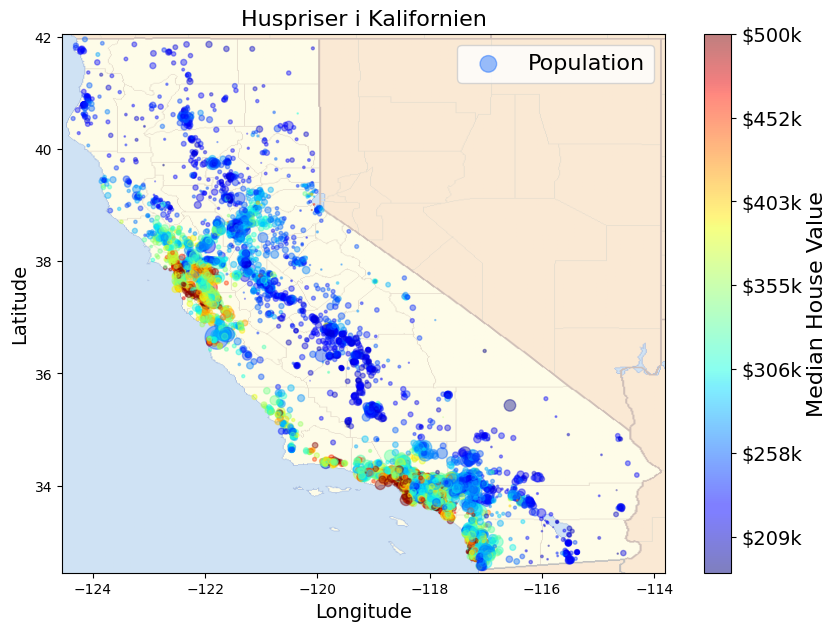

In [6]:
# Ladda Kalifornien-karta (du behöver ha california.png i samma mapp)
try:
    california_img = mpimg.imread('california.png')
    
    # Skapa scatter plot över Kalifornien
    ax = train.plot(kind="scatter", x="longitude", y="latitude",
                    figsize=(10, 7),
                    s=train['population']/100,  # Punktstorlek baserat på befolkning
                    label="Population",
                    c="median_house_value",  # Färg baserat på huspris
                    cmap=plt.get_cmap("jet"),
                    colorbar=False, alpha=0.4)
    
    # Lägg till Kalifornien-karta som bakgrund
    plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], 
               alpha=0.5, cmap=plt.get_cmap("jet"))
    
    # Sätt etiketter och titel
    plt.ylabel("Latitude", fontsize=14)
    plt.xlabel("Longitude", fontsize=14)
    
    # Skapa färgbar med prisintervall
    prices = train["median_house_value"]
    tick_values = np.linspace(prices.min(), prices.max(), 11)
    cbar = plt.colorbar(ticks=tick_values/prices.max())
    cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)
    cbar.set_label('Median House Value', fontsize=16)
    plt.legend(fontsize=16)
    plt.title('Huspriser i Kalifornien', fontsize=16)
    plt.show()
    
except FileNotFoundError:
    print("  california.png hittades inte. Skapar scatter plot utan karta.")
    
    # Skapa scatter plot utan karta
    plt.figure(figsize=(10, 7))
    plt.scatter(train['longitude'], train['latitude'], 
                s=train['population']/100, 
                c=train['median_house_value'], 
                cmap='jet', alpha=0.6)
    plt.colorbar(label='Median House Value')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Huspriser i Kalifornien')
    plt.show()

##  7. Korrelationsanalys

Vi analyserar korrelationer mellan variabler.

 Korrelation med median_house_value (sorterat):
median_house_value    1.000000
median_income         0.689648
dmy_<1H OCEAN         0.253893
dmy_NEAR BAY          0.159601
dmy_NEAR OCEAN        0.148101
total_rooms           0.132945
housing_median_age    0.099810
households            0.063797
total_bedrooms        0.048099
population           -0.025675
longitude            -0.043444
latitude             -0.147407
dmy_INLAND           -0.485680
Name: median_house_value, dtype: float64


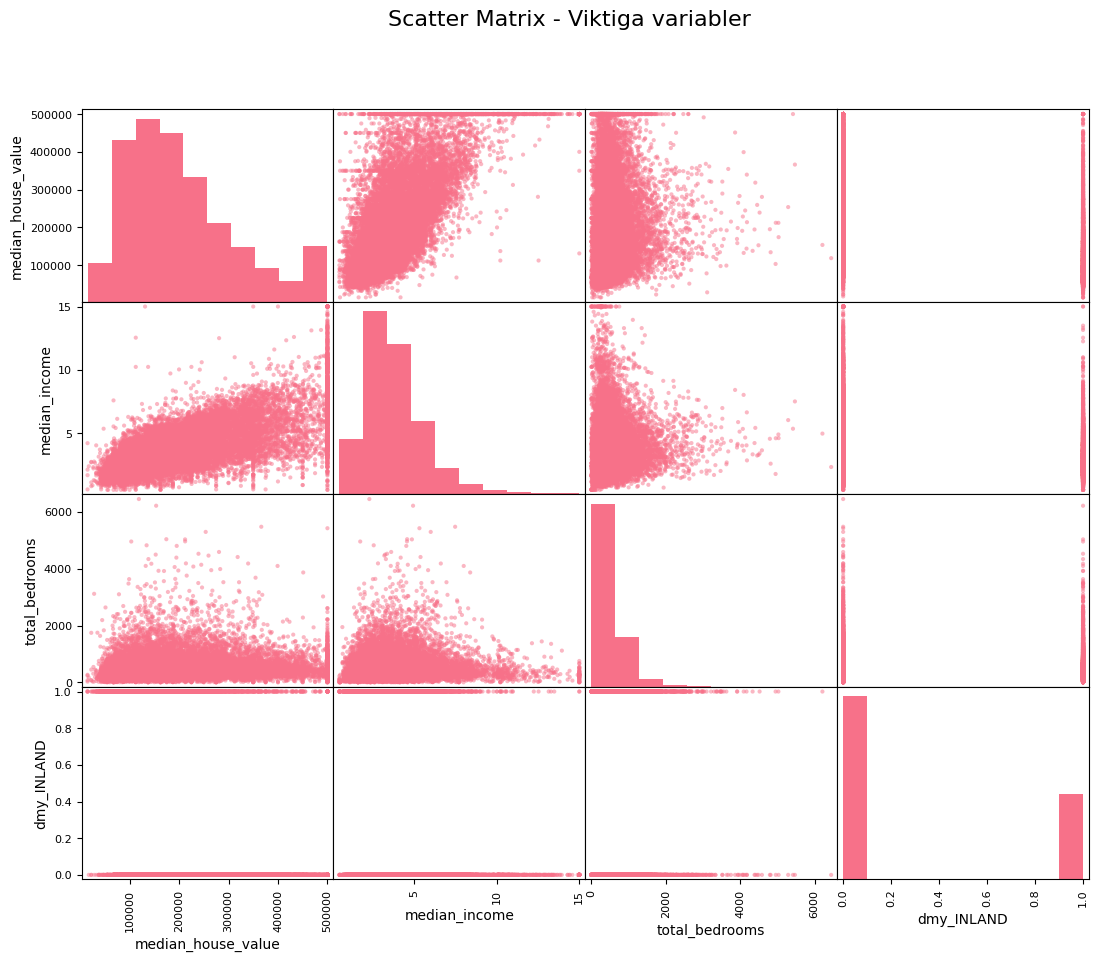

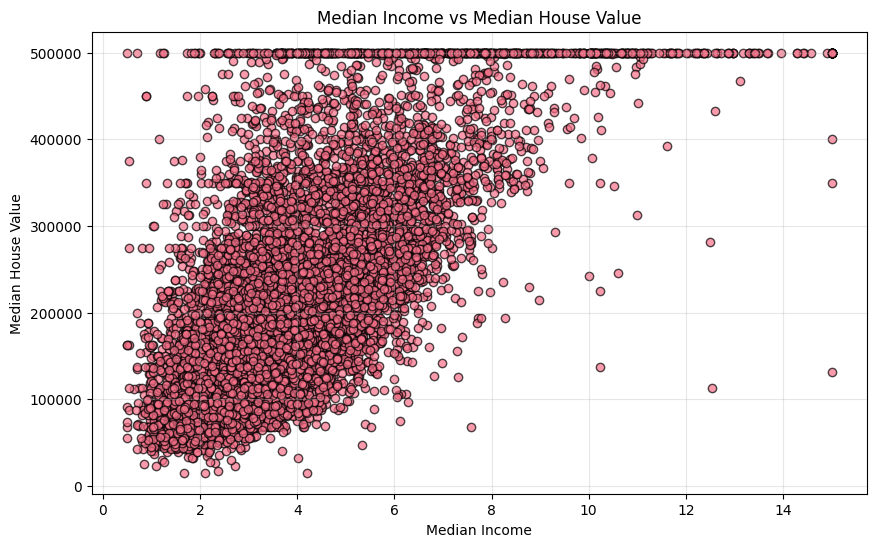

In [7]:
# Beräkna korrelationsmatris
corr_matrix = train.corr()

print(" Korrelation med median_house_value (sorterat):")
print(corr_matrix["median_house_value"].sort_values(ascending=False))

# Skapa scatter matrix för viktiga variabler
attributes = ["median_house_value", "median_income", "total_bedrooms", "dmy_INLAND"]
pd.plotting.scatter_matrix(housing[attributes], figsize=(13, 10))
plt.suptitle('Scatter Matrix - Viktiga variabler', fontsize=16)
plt.show()

# Scatter plot: Median Income vs House Value
plt.figure(figsize=(10, 6))
plt.scatter(train['median_income'], train['median_house_value'], 
            alpha=0.7, edgecolor='k')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Median Income vs Median House Value')
plt.grid(True, alpha=0.3)
plt.show()

##  8. Boxplots för ocean proximity

Vi jämför huspriser mellan olika ocean proximity kategorier.

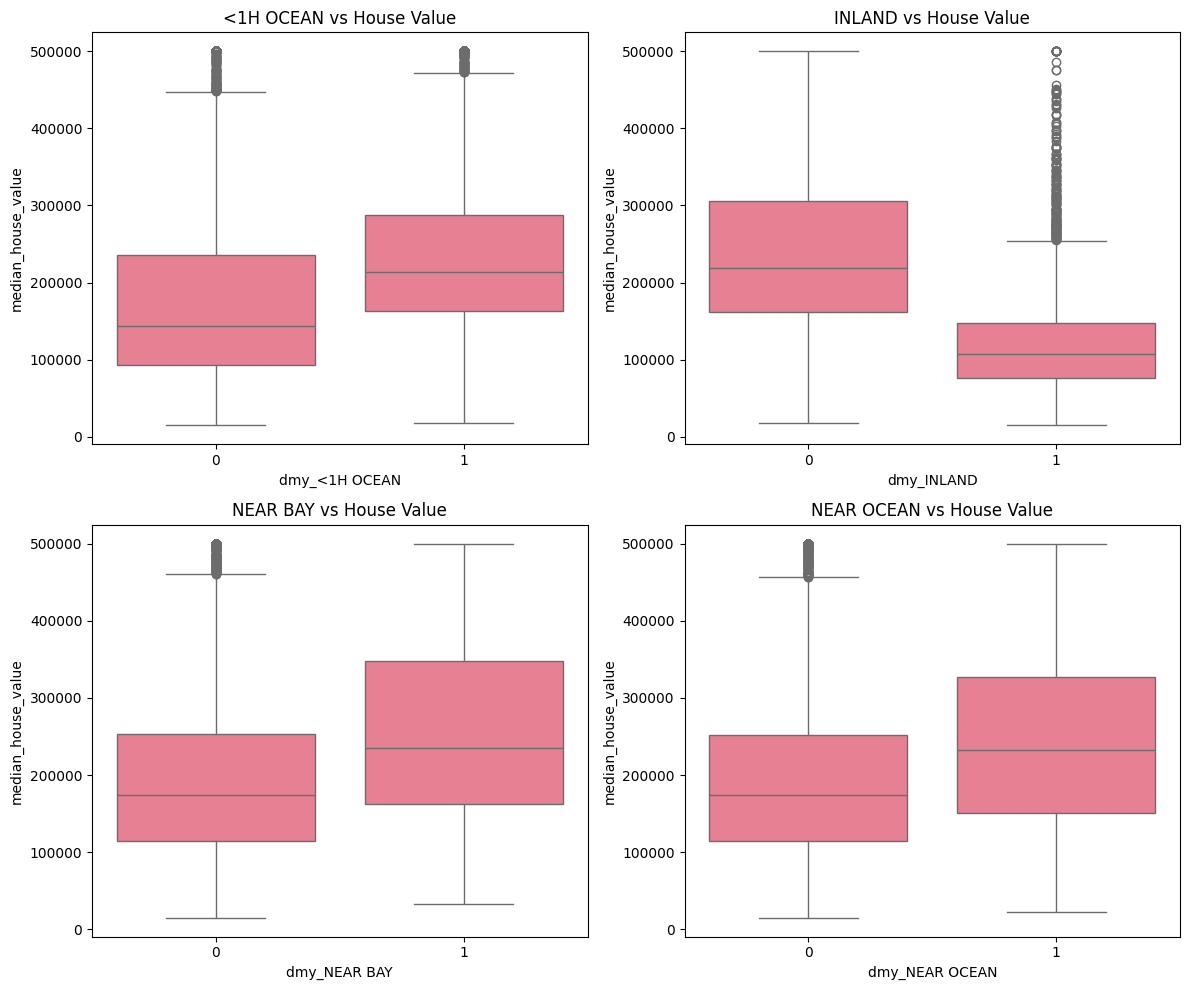

In [8]:
# Skapa boxplots för olika ocean proximity kategorier
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Boxplot för <1H OCEAN
sns.boxplot(data=train, x='dmy_<1H OCEAN', y='median_house_value', ax=axes[0, 0])
axes[0, 0].set_title('<1H OCEAN vs House Value')

# Boxplot för INLAND
sns.boxplot(data=train, x='dmy_INLAND', y='median_house_value', ax=axes[0, 1])
axes[0, 1].set_title('INLAND vs House Value')

# Boxplot för NEAR BAY
sns.boxplot(data=train, x='dmy_NEAR BAY', y='median_house_value', ax=axes[1, 0])
axes[1, 0].set_title('NEAR BAY vs House Value')

# Boxplot för NEAR OCEAN
sns.boxplot(data=train, x='dmy_NEAR OCEAN', y='median_house_value', ax=axes[1, 1])
axes[1, 1].set_title('NEAR OCEAN vs House Value')

plt.tight_layout()
plt.show()

##  9. Förbereda data för modellering

Vi delar upp data i features (X) och target (y) för alla dataset.

In [9]:
# Förbereda data för träning_full (används för slutlig modell)
X_train_full = train_full.drop(columns=['median_house_value'])
y_train_full = train_full['median_house_value']

# Förbereda data för träning, validering och test
X_train, y_train = train.drop(columns=['median_house_value']), train['median_house_value']
X_val, y_val = val.drop(columns=['median_house_value']), val['median_house_value']
X_test, y_test = test.drop(columns=['median_house_value']), test['median_house_value']

print(" Datauppdelning för modellering:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

 Datauppdelning för modellering:
X_train shape: (12261, 12)
y_train shape: (12261,)
X_val shape: (4084, 12)
y_val shape: (4084,)
X_test shape: (4083, 12)
y_test shape: (4083,)


##  10. Träna Linear Regression

Vi börjar med en enkel Linear Regression som baseline.

In [10]:
# Skapa och träna Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print(" Linear Regression tränad!")
print(f"Antal features: {len(lin_reg.coef_)}")
print(f"Intercept: {lin_reg.intercept_:.2f}")
print(f"Första 5 koefficienter: {lin_reg.coef_[:5]}")

 Linear Regression tränad!
Antal features: 12
Intercept: -2313130.87
Första 5 koefficienter: [-2.73381731e+04 -2.62001396e+04  1.00265462e+03 -5.08088982e+00
  9.97405414e+01]


##  11. Hyperparameteroptimering med Random Forest

Vi använder GridSearchCV för att hitta bästa hyperparametrarna för Random Forest.

In [11]:
import time

# Starta tidtagning
start_time = time.time()

# Skapa Random Forest
rf = RandomForestRegressor()

# Definiera hyperparameter grid
hyperparam_grid = {
    'max_depth': [5, 10, 15, 50], 
    'n_estimators': [1, 5, 10]
}

# Skapa GridSearchCV
# Notera: Vi använder mean_squared_error istället för root_mean_squared_error
grid_search = GridSearchCV(rf, hyperparam_grid, 
                          scoring='neg_mean_squared_error', cv=5)

# Träna GridSearchCV
grid_search.fit(X_train, y_train)

# Stoppa tidtagning
end_time = time.time()
execution_time = end_time - start_time

print(f"⏱  GridSearchCV träning tog {execution_time:.4f} sekunder.")
print(f" Bästa hyperparametrar: {grid_search.best_params_}")
print(f" Bästa score: {-grid_search.best_score_:.4f} (MSE)")
print(f" Bästa RMSE: {np.sqrt(-grid_search.best_score_):.4f}")

⏱  GridSearchCV träning tog 19.5799 sekunder.
 Bästa hyperparametrar: {'max_depth': 50, 'n_estimators': 10}
 Bästa score: 2800129338.9256 (MSE)
 Bästa RMSE: 52916.2483


##  12. Jämföra modeller på valideringsdata

Vi jämför Linear Regression och Random Forest på valideringsdata.

In [12]:
# Gör prediktioner på valideringsdata
lr_pred_val = lin_reg.predict(X_val)
rf_pred_val = grid_search.predict(X_val)

# Beräkna RMSE (vi använder mean_squared_error och tar roten)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_pred_val))
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred_val))

print(" Modelljämförelse på valideringsdata:")
print(f"RMSE Linear Regression: {lr_rmse:.4f}")
print(f"RMSE Random Forest: {rf_rmse:.4f}")

# Beräkna relativt fel
print(f"\n Relativt fel (RMSE / medelvärde):")
print(f"Medelvärde av target: {np.mean(y_val):.2f}")
print(f"Relativt fel Random Forest: {rf_rmse/np.mean(y_val):.4f}")

 Modelljämförelse på valideringsdata:
RMSE Linear Regression: 69442.0953
RMSE Random Forest: 52119.5038

 Relativt fel (RMSE / medelvärde):
Medelvärde av target: 207517.11
Relativt fel Random Forest: 0.2512


##  13. Analysera prediktionsfel

Vi analyserar fördelningen av prediktionsfel.

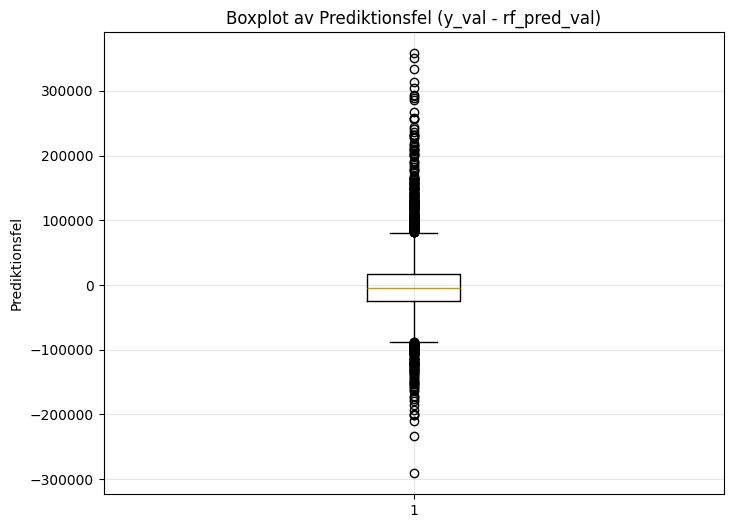

 Felstatistik:
Medelvärde av fel: -413.1943
Standardavvikelse av fel: 52117.8659
Min fel: -290890.4000
Max fel: 358080.0000


In [13]:
# Beräkna prediktionsfel
errors = y_val - rf_pred_val

# Skapa boxplot av fel
plt.figure(figsize=(8, 6))
plt.boxplot(errors)
plt.title('Boxplot av Prediktionsfel (y_val - rf_pred_val)')
plt.ylabel('Prediktionsfel')
plt.grid(True, alpha=0.3)
plt.show()

print(f" Felstatistik:")
print(f"Medelvärde av fel: {np.mean(errors):.4f}")
print(f"Standardavvikelse av fel: {np.std(errors):.4f}")
print(f"Min fel: {np.min(errors):.4f}")
print(f"Max fel: {np.max(errors):.4f}")

##  14. Träna slutlig modell

Vi tränar den bästa modellen på all träningsdata.

In [14]:
# Hämta bästa hyperparametrar
best_params = grid_search.best_params_
print(f" Bästa hyperparametrar: {best_params}")

# Skapa och träna slutlig modell på all träningsdata
best_rf = RandomForestRegressor(**best_params)
best_rf.fit(X_train_full, y_train_full)

print(" Slutlig modell tränad på all träningsdata!")
print(f"Modellparametrar: {best_rf.get_params()}")

 Bästa hyperparametrar: {'max_depth': 50, 'n_estimators': 10}
 Slutlig modell tränad på all träningsdata!
Modellparametrar: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 50, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 10, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
 Slutlig modell tränad på all träningsdata!
Modellparametrar: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 50, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 10, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


##  15. Utvärdera på testdata

Vi utvärderar den slutliga modellen på testdata.

 Utvärdering på testdata:
RMSE Random Forest på testdata: 50433.4388
Relativt fel: 0.2439


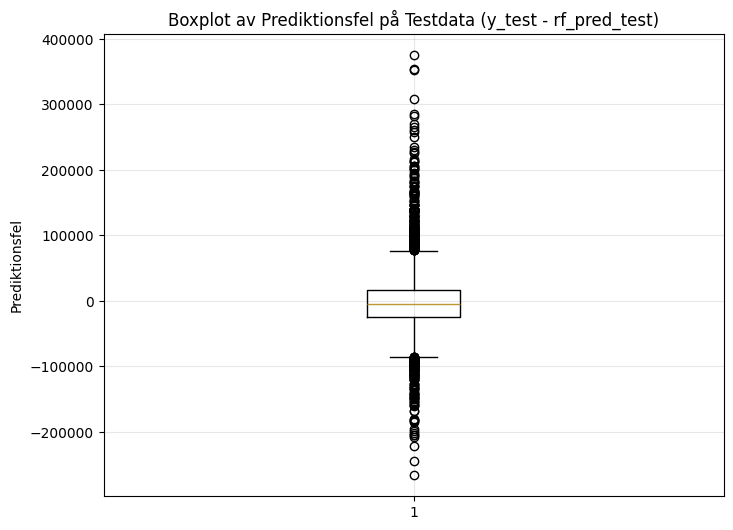

 Testfelstatistik:
Medelvärde av fel: -1465.5660
Standardavvikelse av fel: 50412.1400


In [15]:
# Gör prediktioner på testdata
rf_pred_test = best_rf.predict(X_test)

# Beräkna RMSE
rmse_test = np.sqrt(mean_squared_error(y_test, rf_pred_test))

print(" Utvärdering på testdata:")
print(f"RMSE Random Forest på testdata: {rmse_test:.4f}")
print(f"Relativt fel: {rmse_test/np.mean(y_test):.4f}")

# Analysera prediktionsfel på testdata
errors = y_test - rf_pred_test

plt.figure(figsize=(8, 6))
plt.boxplot(errors)
plt.title('Boxplot av Prediktionsfel på Testdata (y_test - rf_pred_test)')
plt.ylabel('Prediktionsfel')
plt.grid(True, alpha=0.3)
plt.show()

print(f" Testfelstatistik:")
print(f"Medelvärde av fel: {np.mean(errors):.4f}")
print(f"Standardavvikelse av fel: {np.std(errors):.4f}")

##  16. Spara modellen

Vi sparar den tränade modellen för framtida användning.

In [16]:
# Förbereda data för slutlig modell (hela dataset)
X_full = housing.drop(columns=['median_house_value'])
y_full = housing['median_house_value']

# Skapa och träna modell för sparande
saved_model = RandomForestRegressor(**best_params)
saved_model.fit(X_full, y_full)

# Spara modellen
joblib.dump(saved_model, 'rf_saved_model.pkl')

print(" Modell sparad som 'rf_saved_model.pkl'!")
print(f"Modell tränad på {X_full.shape[0]} observationer med {X_full.shape[1]} features")

 Modell sparad som 'rf_saved_model.pkl'!
Modell tränad på 20635 observationer med 12 features


##  17. Gör prediktioner på nya data

Vi demonstrerar hur man använder den sparade modellen för att prediktera huspriser för nya distrikt.

In [17]:
# Skapa nya distrikt för prediktion
new_districts = pd.DataFrame({
    'longitude': [-118.30, -117.85],
    'latitude': [34.20, 33.90],
    'housing_median_age': [35.0, 20.0],
    'total_rooms': [880.0, 1200.0],
    'total_bedrooms': [200.0, 300.0],
    'population': [500.0, 750.0],
    'households': [220.0, 280.0],
    'median_income': [4.2, 5.1],
    'dmy_<1H OCEAN': [0, 1],
    'dmy_INLAND': [1, 0],
    'dmy_NEAR BAY': [0, 0],
    'dmy_NEAR OCEAN': [0, 0]
})

print(" Nya distrikt för prediktion:")
print(new_districts)

# Gör prediktioner
predicted_values = saved_model.predict(new_districts)

print("\n Predikterade huspriser:")
for i, value in enumerate(predicted_values, start=1):
    print(f"Predikterat medianhuspris för distrikt {i}: ${value:,.2f}")

print("\n Prediktioner slutförda!")

 Nya distrikt för prediktion:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -118.30      34.2                35.0        880.0           200.0   
1    -117.85      33.9                20.0       1200.0           300.0   

   population  households  median_income  dmy_<1H OCEAN  dmy_INLAND  \
0       500.0       220.0            4.2              0           1   
1       750.0       280.0            5.1              1           0   

   dmy_NEAR BAY  dmy_NEAR OCEAN  
0             0               0  
1             0               0  

 Predikterade huspriser:
Predikterat medianhuspris för distrikt 1: $298,460.00
Predikterat medianhuspris för distrikt 2: $201,210.00

 Prediktioner slutförda!


##  Sammanfattning

###  Vad vi har gjort:

1. **Data laddning**: Laddade California Housing dataset
2. **Data preprocessing**: Rensade data, hanterade saknade värden, skapade dummy-variabler
3. **Exploratory Data Analysis**: Visualiserade data, analyserade korrelationer
4. **Datauppdelning**: Delade upp i träning (60%), validering (20%), test (20%)
5. **Modellering**: Tränade Linear Regression och Random Forest
6. **Hyperparameteroptimering**: Använde GridSearchCV för att hitta bästa parametrar
7. **Utvärdering**: Jämförde modeller och analyserade prediktionsfel
8. **Modellsparning**: Sparade den bästa modellen för framtida användning
9. **Prediktioner**: Demonsterade hur man använder modellen för nya data

###  Nyckelresultat:
- **Random Forest** presterade bättre än Linear Regression
- Modellen kan prediktera huspriser med relativt lågt fel
- Modellen är sparad och kan användas för nya prediktioner

###  Nästa steg:
- Experimentera med fler modeller (XGBoost, Neural Networks)
- Testa feature engineering
- Implementera cross-validation
- Deploya modellen i produktion

---

**Lycka till med dina ML-projekt! **